# Uma amplitude não é um qubit inteiro

Um estado **puro** é representado por $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$, com $|\alpha|^2+|\beta|^2=1$. Vamos desenhar as duas amplitudes e as probabilidades de medição **na base computacional**. [Leia a ponte](../docs/06_ponte_para_qubits.md).

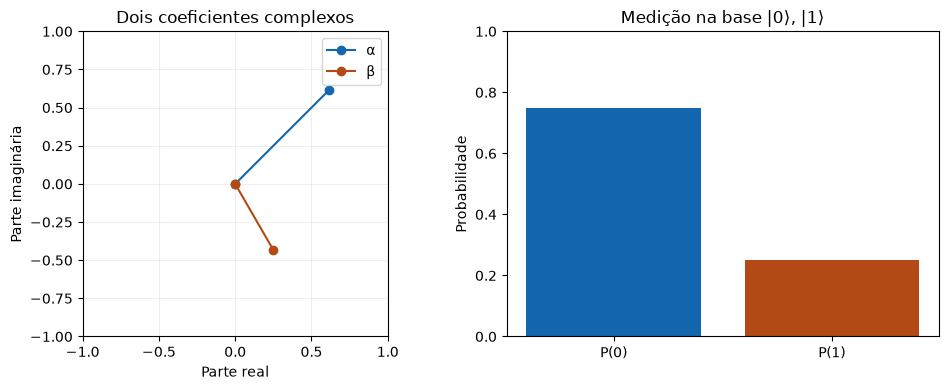

Soma das probabilidades: 1.0000000000000004


In [1]:
import sys
from pathlib import Path

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src' / 'complex_geometry.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Abra o notebook dentro da pasta do projeto.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
alpha = np.sqrt(.75)*np.exp(1j*np.pi/4)
beta = np.sqrt(.25)*np.exp(-1j*np.pi/3)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for value, label, color in [(alpha, 'α', '#1467ae'), (beta, 'β', '#b34a16')]:
    axes[0].plot([0, value.real], [0, value.imag], 'o-', label=label, color=color)
axes[0].set(xlabel='Parte real', ylabel='Parte imaginária', aspect='equal', xlim=(-1,1), ylim=(-1,1), title='Dois coeficientes complexos')
axes[0].legend(); axes[0].grid(alpha=.2)
probabilities = np.abs([alpha, beta])**2
axes[1].bar(['P(0)', 'P(1)'], probabilities, color=['#1467ae','#b34a16'])
axes[1].set(ylim=(0,1), title='Medição na base |0⟩, |1⟩', ylabel='Probabilidade')
fig.tight_layout(); plt.show()
print('Soma das probabilidades:', probabilities.sum())
assert np.isclose(probabilities.sum(), 1)

## Janela para fase relativa e mudança de base

$|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$ e $|-\rangle=(|0\rangle-|1\rangle)/\sqrt2$ têm as mesmas probabilidades na base computacional. Na base ortonormal $|+\rangle,|-\rangle$, as coordenadas são $(\alpha+\beta)/\sqrt2$ e $(\alpha-\beta)/\sqrt2$: a soma reforça um caso e cancela o outro.

O gráfico compara **duas bases de medição**. A teoria geral exige produto interno e álgebra linear; aqui mostramos uma consequência calculável.

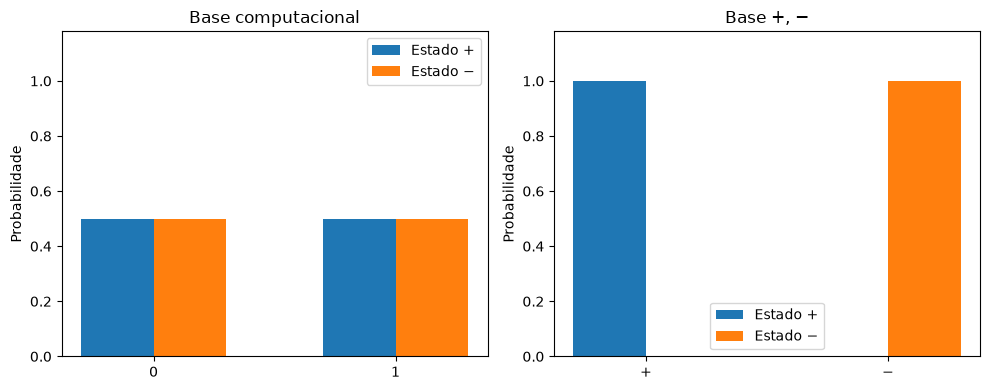

In [2]:
states = np.array([[1, 1], [1, -1]], dtype=complex)/np.sqrt(2)
change_basis = np.array([[1, 1], [1, -1]])/np.sqrt(2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, transform, labels, title in zip(axes, [np.eye(2), change_basis],
        [['0', '1'], ['+', '−']], ['Base computacional', 'Base +, −']):
    for i, (state, name) in enumerate(zip(states, ['Estado +', 'Estado −'])):
        probs = abs(transform @ state)**2
        ax.bar(np.arange(2)+(i-.5)*.3, probs, width=.3, label=name)
        assert np.isclose(probs.sum(), 1)
    ax.set(xticks=[0,1], xticklabels=labels, ylim=(0,1.18), ylabel='Probabilidade', title=title)
    ax.legend()
fig.tight_layout(); plt.show()

## Observe uma fase global

Multiplicar todas as coordenadas por $e^{i\chi}$ preserva as probabilidades em ambas as bases. Uma fase global não muda o estado físico; uma fase relativa entre amplitudes não nulas pode mudar.

[IBM — fases global e relativa](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/limitations-on-quantum-information) · [TU Delft — regra de Born](https://ocw.tudelft.nl/course-lectures/1-2-1-born-rule/).

In [3]:
state = np.array([alpha, beta])
rotated = np.exp(1j*1.2)*state
for basis in [np.eye(2), change_basis]:
    print('Antes:', abs(basis @ state)**2, 'Depois:', abs(basis @ rotated)**2)
    assert np.allclose(abs(basis @ state)**2, abs(basis @ rotated)**2)

Antes: [0.75 0.25] Depois: [0.75 0.25]
Antes: [0.38792807 0.61207193] Depois: [0.38792807 0.61207193]


[Explore magnitudes e fases com controles](06_laboratorio_interativo.ipynb#amplitudes) · [Volte ao livro](../README.md).